----------------------------------------------------------------
# **Customer Spending Segmentation for a Wholesale Distributor**
##### Using PCA + K-Means Clustering on Multi-Category Spending Data
----------------------------------------------------------------

-----------------------------------------------------------
### BUSINESS PROBLEM
-----------------------------------------------------------
A wholesale distributor sells products across six categories to
different types of clients (retailers, cafes, hotels). They currently
have no clear way to group clients by purchasing behavior across all
categories at once. The goal is to discover natural client segments
based on spending patterns, so the business can tailor sales strategy,
delivery frequency, and bulk discount offers per segment.
      
**Business question**: "What natural client types exist based on spending
across all product categories, and how do we describe each simply
enough to act on?"

-----------------------------------------------------------
## ABOUT THE DATA
-----------------------------------------------------------
**Dataset** : Wholesale Customers (UCI, real data) - 440 clients  
**Channel** : 1 = Horeca (Hotel/Restaurant/Cafe), 2 = Retail  
**Region**  : 1 = Lisbon, 2 = Oporto, 3 = Other region (Portugal)  
**Spending features (annual, monetary units)** :  Fresh, Milk, Grocery, Frozen, Detergents_Paper, Delicassen

In [1]:
# Load and import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
wholesale = pd.read_csv('./data/Wholesale_Customer_data.csv')

In [3]:
wholesale.sample(5)

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
342,1,3,255,5758,5923,349,4595,1328
135,1,3,6300,1289,2591,1170,199,326
152,1,3,18840,1371,3135,3001,352,184
384,1,3,10683,21858,15400,3635,282,5120
5,2,3,9413,8259,5126,666,1795,1451


In [4]:
wholesale.shape

(440, 8)

In [5]:
wholesale.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


-----------------------------------------------------------
## DATA PREPROCESSING
-----------------------------------------------------------

In [6]:
# Handle missing values
wholesale.isnull().sum()

Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

In [7]:
# Handle duplicate rows
wholesale.duplicated().sum()

np.int64(0)

Nothing to handle in duplicates and nulls.

In [8]:
# Separate categorical/label columns from the spending features.
# Channel and Region are real, meaningful info, but they are category
# codes, not spending amounts -- distance-based clustering shouldn't
# use them directly. We keep them aside to validate our clusters later
labels = wholesale[['Channel', 'Region']]
spending = wholesale.drop(['Channel', 'Region'], axis=1)

In [9]:
spending.describe()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


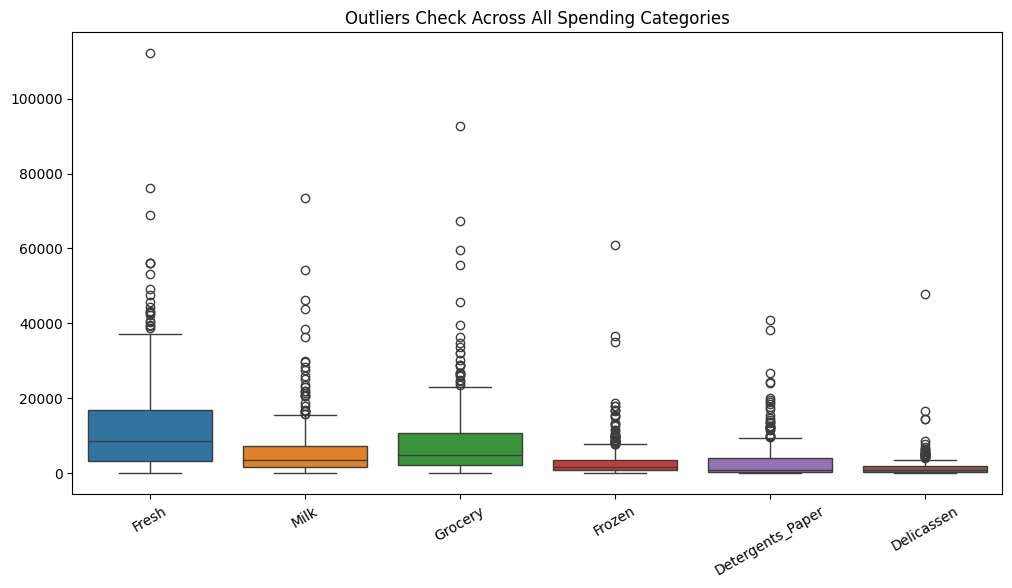

In [10]:
# Detecting outliers across all 6 spending categories at once
plt.figure(figsize= (12,6))
sns.boxplot(data = spending)
plt.title("Outliers Check Across All Spending Categories")
plt.xticks(rotation = 30)
plt.savefig('outputs/outlier_check.png', dpi=150, bbox_inches='tight')
plt.show()

### DECISION :
These are not data errors.   
B2B wholesale spending is naturally skewed -- a small cafe spends modestly, a big hotel chain
spends 10-50x more, and both are real, valid clients. We keep every
row.    
However, the skew itself is a real problem for K-Means/PCA
(both rely on distance), so we address the SHAPE of the data next,
rather than deleting anything.


In [11]:
#Checking exactly how skewed each column is
print("Skewness BEFORE log transform:")
print(spending.skew().round(2))

Skewness BEFORE log transform:
Fresh                2.56
Milk                 4.05
Grocery              3.59
Frozen               5.91
Detergents_Paper     3.63
Delicassen          11.15
dtype: float64


Skewness near 0 = symmetric. These columns are all strongly positive  
(long tail on the high side) -- confirmed by the boxplot above.
 
Applying a log transform to compress the long tail of extreme spenders
without deleting them. log1p(x) = log(1 + x); the "+1" avoids an
undefined log(0) for any very small spending values.

In [12]:
spending_log = np.log1p(spending)
print("Skewness AFTER log transform:")
print(spending_log.skew().round(2))

Skewness AFTER log transform:
Fresh              -1.58
Milk               -0.22
Grocery            -0.67
Frozen             -0.35
Detergents_Paper   -0.24
Delicassen         -1.09
dtype: float64


### Visual Check: Raw vs Log-Transformed Distribution
Before committing to the log transform, let's visually confirm what it 
actually does to the shape of a skewed column (using Fresh as an example).


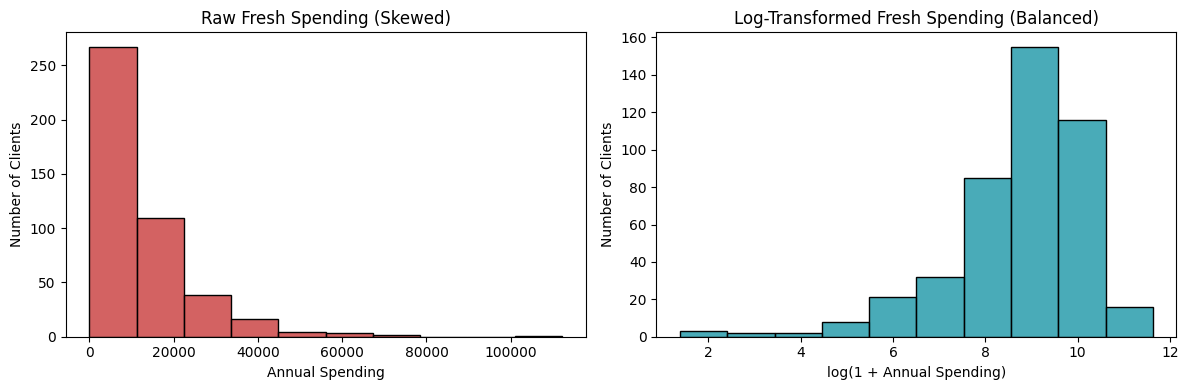

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: raw distribution (skewed)
sns.histplot(spending['Fresh'], bins=10, color="#C52E2E", ax=axes[0])
axes[0].set_title('Raw Fresh Spending (Skewed)')
axes[0].set_xlabel('Annual Spending')
axes[0].set_ylabel('Number of Clients')

# Right: log-transformed distribution (balanced)
sns.histplot(spending_log['Fresh'], bins=10, color="#0C8FA0", ax=axes[1])
axes[1].set_title('Log-Transformed Fresh Spending (Balanced)')
axes[1].set_xlabel('log(1 + Annual Spending)')
axes[1].set_ylabel('Number of Clients')

plt.tight_layout()
plt.savefig('outputs/fresh_raw_vs_log.png', dpi=150, bbox_inches='tight')
plt.show()

-----------------------------------------------------------
## EXPLORATORY DATA ANALYSIS
-----------------------------------------------------------
Now that spending is log-transformed and more balanced, we explore two 
things: how spending categories relate to each other, and whether 
spending patterns differ by Channel (Horeca vs Retail) or Region.

In [14]:
channel_map = {1: 'Horeca', 2: 'Retail'}
region_map = {1: 'Lisbon', 2: 'Oporto', 3: 'Other'}

wholesale['Channel_Label'] = wholesale['Channel'].map(channel_map)
wholesale['Region_Label'] = wholesale['Region'].map(region_map)

### Correlation Between Spending Categories

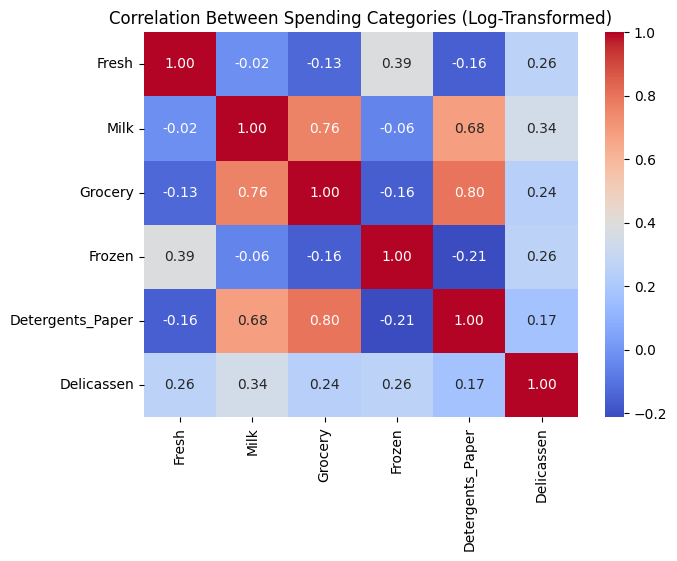

In [15]:
plt.figure(figsize=(7, 5))
sns.heatmap(spending_log.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Spending Categories (Log-Transformed)')
plt.savefig('outputs/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Spending Patterns by Channel (Horeca vs Retail)

                 Fresh     Milk  Grocery  Frozen  Detergents_Paper  Delicassen
Channel_Label                                                                 
Horeca         13475.6   3451.7   3962.1  3748.3             790.6      1416.0
Retail          8904.3  10716.5  16322.9  1652.6            7269.5      1753.4


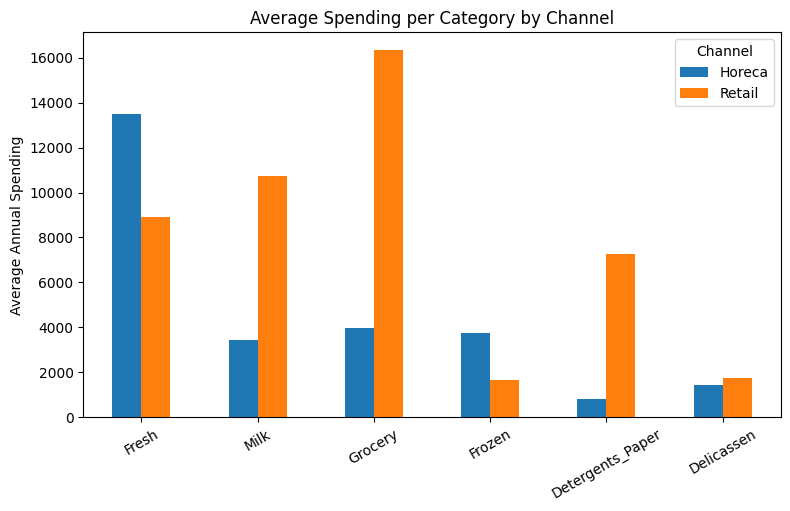

In [16]:
channel_spending = wholesale.groupby('Channel_Label')[
    ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
].mean().round(1)

print(channel_spending)

channel_spending.T.plot(kind='bar', figsize=(9, 5))
plt.title('Average Spending per Category by Channel')
plt.ylabel('Average Annual Spending')
plt.xticks(rotation=30)
plt.legend(title='Channel')
plt.savefig('outputs/channel_spending.png', dpi=150, bbox_inches='tight')
plt.show()

## Feature Scaling
K-Means and PCA both rely on distance and variance calculations, so 
we standardize the log-transformed spending data before proceeding — 
this ensures no single category dominates just because of its numeric 
range.

In [17]:
scaler = StandardScaler()
spending_scaled = scaler.fit_transform(spending_log)

# After scaling, every column should have
# mean approx 0 and standard deviation approx 1
print("Mean after scaling:", spending_scaled.mean(axis=0).round(2))
print("Std after scaling:", spending_scaled.std(axis=0).round(2))

Mean after scaling: [ 0. -0. -0.  0. -0. -0.]
Std after scaling: [1. 1. 1. 1. 1. 1.]


## Applying PCA (Dimensionality Reduction)
With 6 correlated spending features, we use PCA to compress them into 
a smaller number of components that still capture most of the real 
variation between clients — making the data easier to cluster and 
visualize.

In [18]:
pca = PCA()
pca.fit(spending_scaled)

explained_variance = pca.explained_variance_ratio_
print("Explained variance per component:", explained_variance.round(3))
print("Cumulative explained variance:", explained_variance.cumsum().round(3))

Explained variance per component: [0.441 0.272 0.107 0.101 0.049 0.03 ]
Cumulative explained variance: [0.441 0.713 0.82  0.921 0.97  1.   ]


### Choosing How Many Components to Keep
We use a cumulative explained variance plot to decide how many 
components retain enough information (commonly 80-90%+) while still 
simplifying the data meaningfully.

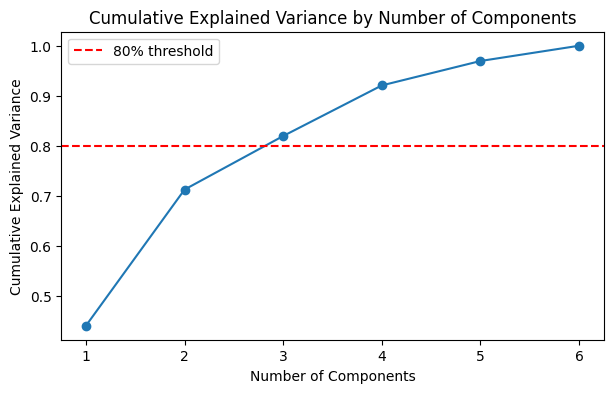

In [19]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, 7), pca.explained_variance_ratio_.cumsum(), marker='o')
plt.axhline(y=0.80, color='red', linestyle='--', label='80% threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance by Number of Components')
plt.xticks(range(1, 7))
plt.legend()
plt.savefig('outputs/pca_variance_plot.png', dpi=150, bbox_inches='tight')
plt.show()

### Reducing to 2 Principal Components
We retain 2 components (71.3% of total variance) — enough to capture 
the dominant spending patterns while keeping results visualizable in 2D.

In [20]:
pca_final = PCA(n_components=2)
spending_pca = pca_final.fit_transform(spending_scaled)

print("Shape before PCA:", spending_scaled.shape)
print("Shape after PCA:", spending_pca.shape)

Shape before PCA: (440, 6)
Shape after PCA: (440, 2)


In [21]:
loadings = pd.DataFrame(
    pca_final.components_,
    columns=spending_log.columns,
    index=['PC1', 'PC2']
)
print(loadings.round(2))

     Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
PC1  -0.11  0.54     0.57   -0.14              0.55        0.21
PC2   0.59  0.13    -0.01    0.59             -0.07        0.53


## Choosing Number of Segments


Elbow Method

In [ ]:
inertia = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(spending_pca)
    inertia.append(km.inertia_)

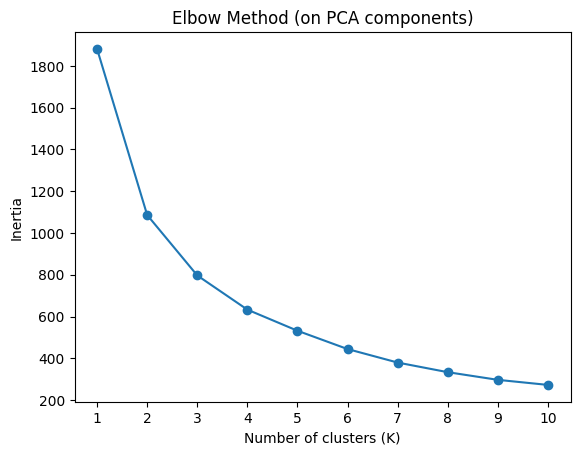

In [25]:
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method (on PCA components)')
plt.xticks(k_range)
plt.savefig('outputs/elbow_plot.png', dpi=150, bbox_inches='tight')
plt.show()


Silhouette Score

In [27]:
silhouette_scores = []
k_range_sil = range(2, 11)

for k in k_range_sil:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = km.fit_predict(spending_pca)
    score = silhouette_score(spending_pca, cluster_labels)
    silhouette_scores.append(score)


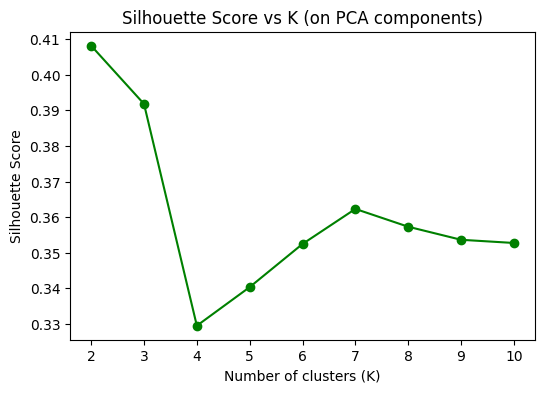

In [28]:
plt.figure(figsize=(6, 4))
plt.plot(k_range_sil, silhouette_scores, marker='o', color='green')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs K (on PCA components)')
plt.xticks(k_range_sil)
plt.savefig('outputs/silhouette_plot.png', dpi=150, bbox_inches='tight')
plt.show()


In [29]:
print(dict(zip(k_range_sil, [round(s, 3) for s in silhouette_scores])))

{2: np.float64(0.408), 3: np.float64(0.392), 4: np.float64(0.329), 5: np.float64(0.34), 6: np.float64(0.352), 7: np.float64(0.362), 8: np.float64(0.357), 9: np.float64(0.354), 10: np.float64(0.353)}


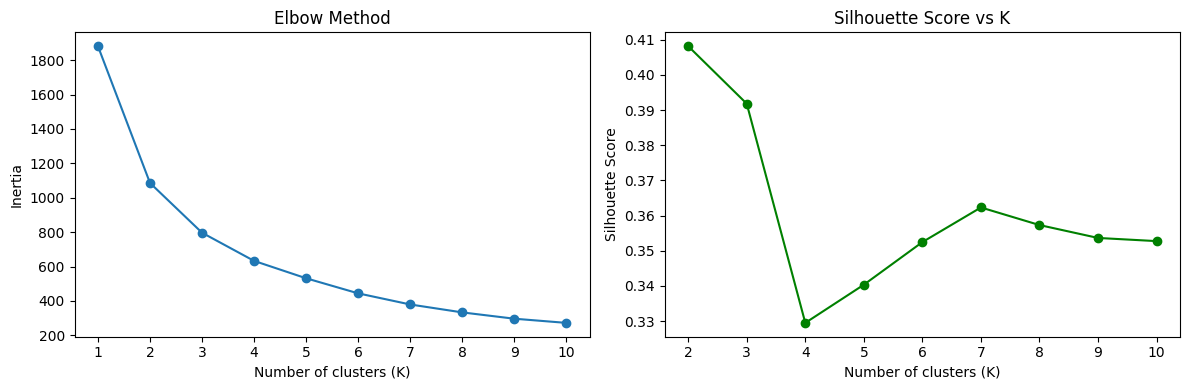

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(k_range, inertia, marker='o')
axes[0].set_xlabel('Number of clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[0].set_xticks(k_range)

axes[1].plot(k_range_sil, silhouette_scores, marker='o', color='green')
axes[1].set_xlabel('Number of clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs K')
axes[1].set_xticks(k_range_sil)

plt.tight_layout()
plt.savefig('outputs/elbow_silhouette_combined.png', dpi=150, bbox_inches='tight')
plt.show()

## Building the Segmentation Model
Based on the Elbow Method and Silhouette Score, we selected K=4 — it 
captures more actionable client segments than a blunt 2-way split, 
while keeping a reasonable silhouette score.

In [31]:
final_k = 4
kmeans = KMeans(n_clusters=final_k, random_state=42, n_init=10)
wholesale['Cluster'] = kmeans.fit_predict(spending_pca)

## Visualizing Customer Segments
Since we reduced spending to 2 PCA components, we can plot every 
client directly, colored by their assigned cluster.

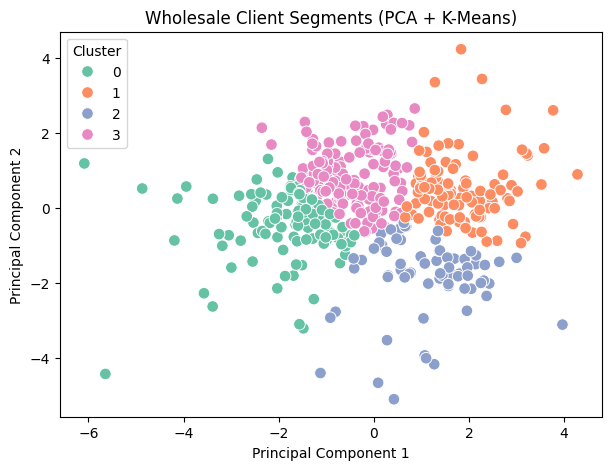

In [32]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x=spending_pca[:, 0], y=spending_pca[:, 1],
                 hue=wholesale['Cluster'], palette='Set2', s=70)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Wholesale Client Segments (PCA + K-Means)')
plt.savefig('outputs/cluster_plot.png', dpi=150, bbox_inches='tight')
plt.show()

## Cross-Checking Clusters Against Channel & Region
K-Means never saw Channel or Region during training. We now check 
whether our discovered spending-based clusters happen to align with 
these real, known client categories.

In [33]:
cluster_vs_channel = pd.crosstab(wholesale['Cluster'], wholesale['Channel_Label'])
print(cluster_vs_channel)

cluster_vs_region = pd.crosstab(wholesale['Cluster'], wholesale['Region_Label'])
print(cluster_vs_region)

Channel_Label  Horeca  Retail
Cluster                      
0                 118       0
1                  18      88
2                  30      42
3                 132      12
Region_Label  Lisbon  Oporto  Other
Cluster                            
0                 21      11     86
1                 18      12     76
2                 10       7     55
3                 28      17     99


In [34]:
cluster_profile = wholesale.groupby('Cluster')[
    ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
].mean().round(0)

print(cluster_profile)


           Fresh     Milk  Grocery  Frozen  Detergents_Paper  Delicassen
Cluster                                                                 
0         9770.0   1430.0   1953.0  2293.0             321.0       553.0
1        12034.0  13078.0  17448.0  3033.0            7272.0      2905.0
2         3272.0   6619.0  11543.0   591.0            4865.0       658.0
3        18167.0   3603.0   4080.0  4979.0             755.0      1739.0
